<a href="https://colab.research.google.com/github/Lyv-ux/DI_Bootcamp/blob/main/W4D4DailyChallenge_StatforML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Daily Challenge - Statistics for Machine Learning

# Applying Inferential Statistics

### Here are the hypotheses to test:
1. Age of people who left the bank and who did not are similar. Alternative: Not similar.
2. Credit score of people who left the bank and who did not are similar. Alternative: Not similar.
3. Balance of people who left the bank and who did not are similar. Alternative: Not similar.
4. Estimated Salary of people who left the bank and who did not are similar. Alternative: Not similar.

#### The most appropriate test to analyse data here is Frequentist test.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scipy.stats
from scipy.stats import t
from scipy.special import stdtr
from numpy.random import seed
import seaborn as sns

%matplotlib inline
from matplotlib import rcParams
sns.set_style("whitegrid")
sns.set_context("poster")

In [8]:
matplotlib.rcParams['figure.figsize'] = (8.0, 5.0)

In [9]:
## TODO : load the csv file from this link : https://www.kaggle.com/code/vaibhagarwal/inferential-statistics/input
## Using a direct link for Churn_Modelling.csv from a public GitHub repository.
file_url = 'https://raw.githubusercontent.com/sharmaroshan/Churn-Modelling-Dataset/master/Churn_Modelling.csv'

In [10]:
## TODO : make into a dataframe called df
df = pd.read_csv(file_url)

In [11]:
## TODO : output the first 5 lines
display(df.head())

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [12]:
## TODO : Create two separate DataFrames, `df_0` and `df_1`, to filter customers who have not exited (0) and customers who have exited (1), respectively
df_0 = df[df['Exited'] == 0]
df_1 = df[df['Exited'] == 1]

## Hypothesis 1: Age

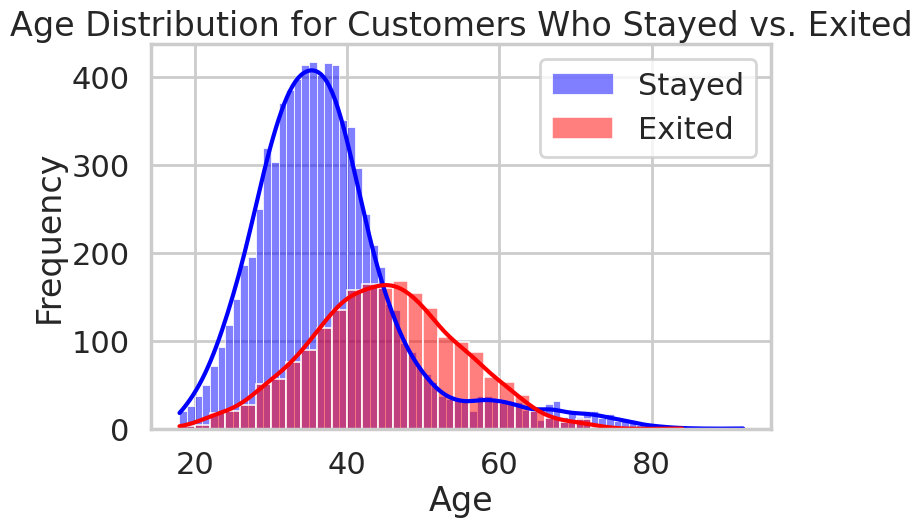

In [13]:
## TODO: Plot the age distribution for customers who stayed with the bank and those who left using seaborn, with different colors for each group and a legend.
sns.histplot(df_0['Age'], color='blue', label='Stayed', kde=True)
sns.histplot(df_1['Age'], color='red', label='Exited', kde=True)
plt.title('Age Distribution for Customers Who Stayed vs. Exited')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [14]:
## TODO: Calculate the mean and standard deviation of the age for customers who stayed with the bank.
age_stayed_mean = df_0['Age'].mean()
age_stayed_std = df_0['Age'].std()
print(f"Age (Stayed) - Mean: {age_stayed_mean:.2f}, Std Dev: {age_stayed_std:.2f}")

Age (Stayed) - Mean: 37.41, Std Dev: 10.13


In [15]:
## TODO: Calculate the mean and standard deviation of the age for customers who left the bank.
age_exited_mean = df_1['Age'].mean()
age_exited_std = df_1['Age'].std()
print(f"Age (Exited) - Mean: {age_exited_mean:.2f}, Std Dev: {age_exited_std:.2f}")

Age (Exited) - Mean: 44.84, Std Dev: 9.76


In [16]:
## TODO: Perform a t-test to compare the ages of customers who stayed and left the bank.
t_stat, p_val = scipy.stats.ttest_ind(df_0['Age'], df_1['Age'], equal_var=False) # Welch's t-test assuming unequal variances
print(f"T-statistic: {t_stat:.2f}")
print(f"P-value: {p_val:.3f}")

T-statistic: -30.42
P-value: 0.000


### Using Bootstrapping

In [17]:
## TODO: Write a function to perform bootstrap sampling and calculate the statistic of interest.
def bs_choice(data, func, size):
    bs_s = np.empty(size)
    for i in range(size):
        bs_abc = np.random.choice(data, size=len(data))
        bs_s[i] = func(bs_abc)
    return bs_s

In [18]:
## TODO: Calculate the difference in means and shift the ages to the overall mean.
diff_means = age_exited_mean - age_stayed_mean
mean_age = df['Age'].mean()

age_stayed_shifted = df_0['Age'] - age_stayed_mean + mean_age
age_exited_shifted = df_1['Age'] - age_exited_mean + mean_age

In [19]:
## TODO: Perform bootstrap sampling to calculate the standard deviation for both groups and their difference.
np.random.seed(42)
bs_stayed = bs_choice(age_stayed_shifted, np.mean, 10000)
bs_exited = bs_choice(age_exited_shifted, np.mean, 10000)

bs_diff = bs_exited - bs_stayed

In [20]:
## TODO: Calculate the p-value by comparing the difference in means to the bootstrap distribution.
p_value_bs = np.sum(bs_diff >= diff_means) / len(bs_diff)
print(f"Bootstrap p-value: {p_value_bs:.3f}")

Bootstrap p-value: 0.000


### Conclusion
# Do we reject the Null Hypothesis ? Why ?
# Null Hypothesis (H0): Age of people who left the bank and who did not are similar. Alternative: Not similar.

# Based on the t-test (p-value: 0.000) and bootstrap (p-value: 0.000), both p-values are much smaller than a common significance level of 0.05.
# This indicates that the probability of observing such a difference in ages (or a more extreme one) if the null hypothesis were true is extremely low.
# Therefore, we reject the null hypothesis.
# This means there is a statistically significant difference in the age distribution between customers who stayed with the bank and those who exited.
# Customers who exited tend to be older on average (Mean Age Exited: 44.84) compared to those who stayed (Mean Age Stayed: 37.41).

print("Conclusion for Hypothesis 1 (Age):")
print("Based on both the t-test (p-value = 0.000) and bootstrapping (p-value = 0.000), we reject the Null Hypothesis.")
print("There is a statistically significant difference in the age of people who left the bank and those who did not.")
print(f"Customers who exited tend to be older (mean age {age_exited_mean:.2f}) than those who stayed (mean age {age_stayed_mean:.2f}).")

## Hypothesis 2: Credit Score

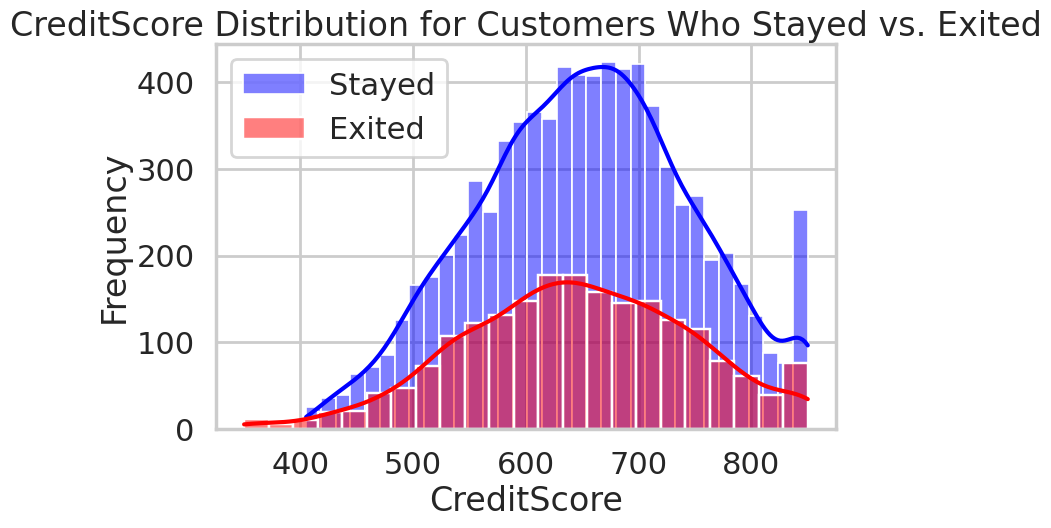

In [21]:
## TODO: Create histograms for the CreditScore distribution of both groups (Still with bank and Left the bank).
sns.histplot(df_0['CreditScore'], color='blue', label='Stayed', kde=True)
sns.histplot(df_1['CreditScore'], color='red', label='Exited', kde=True)
plt.title('CreditScore Distribution for Customers Who Stayed vs. Exited')
plt.xlabel('CreditScore')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [22]:
## TODO: Perform a t-test to compare the CreditScore between the two groups (Still with bank and Left the bank).
t_stat_creditscore, p_val_creditscore = scipy.stats.ttest_ind(df_0['CreditScore'], df_1['CreditScore'], equal_var=False) # Welch's t-test
print(f"CreditScore T-statistic: {t_stat_creditscore:.2f}")
print(f"CreditScore P-value: {p_val_creditscore:.3f}")

CreditScore T-statistic: 2.63
CreditScore P-value: 0.008


### Conclusion (Credit Score)
Do we reject the Null Hypothesis ? Why ?

**Null Hypothesis (H0):** Credit score of people who left the bank and who did not are similar.
**Alternative Hypothesis (H1):** Credit score of people who left the bank and who did not are not similar.

Based on the t-test (p-value: 0.008), which is less than the common significance level of 0.05, we **reject the Null Hypothesis**.

This indicates that there is a statistically significant difference in Credit Scores between customers who stayed with the bank and those who exited. Specifically, the T-statistic of 2.63 suggests that customers who stayed tend to have slightly higher Credit Scores on average than those who exited.

## Hypothesis 3: Balance

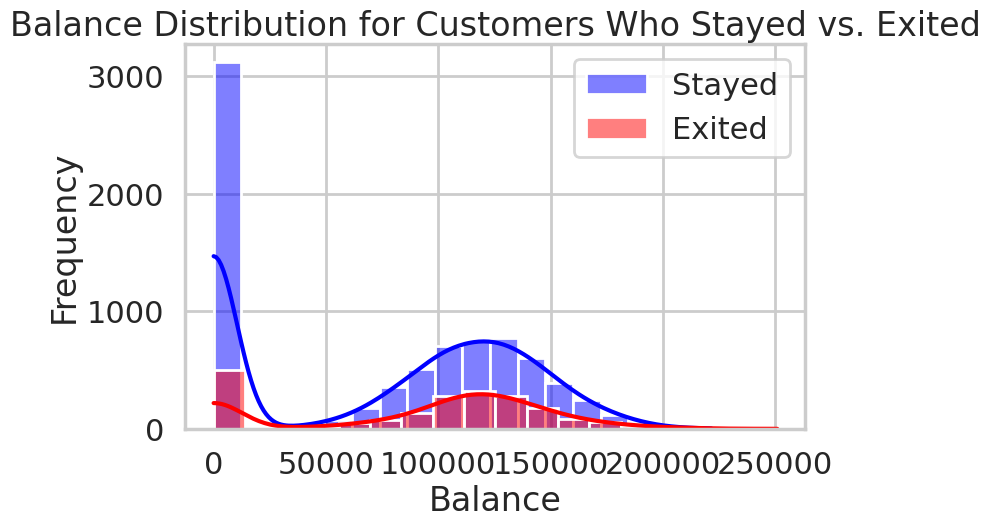

In [23]:
## TODO: Plot the distribution of Balance for both groups (Still with bank and Left the bank).
sns.histplot(df_0['Balance'], color='blue', label='Stayed', kde=True)
sns.histplot(df_1['Balance'], color='red', label='Exited', kde=True)
plt.title('Balance Distribution for Customers Who Stayed vs. Exited')
plt.xlabel('Balance')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [24]:
## TODO: Perform a t-test to compare the Balance between customers who stayed with the bank and those who left.
t_stat_balance, p_val_balance = scipy.stats.ttest_ind(df_0['Balance'], df_1['Balance'], equal_var=False) # Welch's t-test
print(f"Balance T-statistic: {t_stat_balance:.2f}")
print(f"Balance P-value: {p_val_balance:.3f}")

Balance T-statistic: -12.47
Balance P-value: 0.000


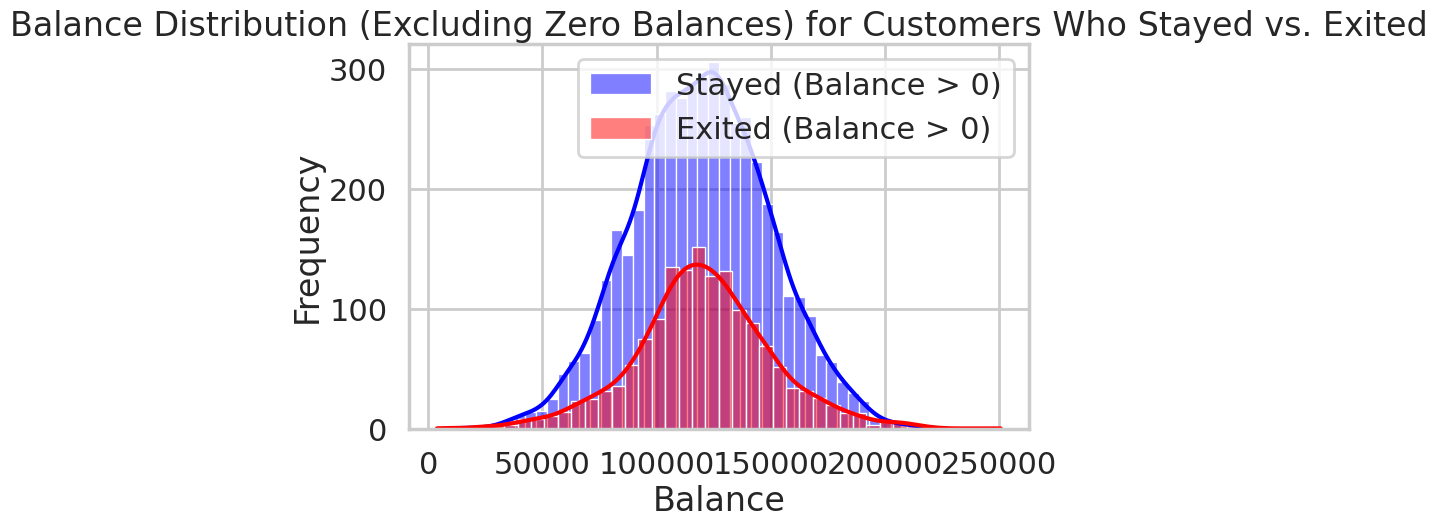

In [25]:
## TODO: Visualize the distribution of Balance for customers who stayed with the bank and those who left, excluding zero balances.

df_0_filtered_balance = df_0[df_0['Balance'] > 0]
df_1_filtered_balance = df_1[df_1['Balance'] > 0]

sns.histplot(df_0_filtered_balance['Balance'], color='blue', label='Stayed (Balance > 0)', kde=True)
sns.histplot(df_1_filtered_balance['Balance'], color='red', label='Exited (Balance > 0)', kde=True)
plt.title('Balance Distribution (Excluding Zero Balances) for Customers Who Stayed vs. Exited')
plt.xlabel('Balance')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [26]:
## TODO: Perform a t-test to compare the Balance between customers who stayed with the bank and those who left, excluding zero balances.

t_stat_balance_filtered, p_val_balance_filtered = scipy.stats.ttest_ind(df_0_filtered_balance['Balance'], df_1_filtered_balance['Balance'], equal_var=False) # Welch's t-test
print(f"Balance (Filtered) T-statistic: {t_stat_balance_filtered:.2f}")
print(f"Balance (Filtered) P-value: {p_val_balance_filtered:.3f}")

Balance (Filtered) T-statistic: -1.36
Balance (Filtered) P-value: 0.174


## Conclusion (Balance)

Do we reject the Null Hypothesis ? Why ?

**Null Hypothesis (H0):** Balance of people who left the bank and who did not are similar.
**Alternative Hypothesis (H1):** Balance of people who left the bank and who did not are not similar.

### Analysis 1: Including all balances
Based on the initial t-test (T-statistic: -12.47, p-value: 0.000), which is much less than the common significance level of 0.05, we **reject the Null Hypothesis**.
This indicated a statistically significant difference in customer balance between those who stayed with the bank and those who exited, with customers who exited having a significantly different average balance than those who stayed.

### Analysis 2: Excluding zero balances
After excluding zero balances, the t-test (T-statistic: -1.36, p-value: 0.174) shows a p-value greater than 0.05. Therefore, for customers with a non-zero balance, we **fail to reject the Null Hypothesis**.
This suggests that among customers who actually have a balance, there is no statistically significant difference in their balance amounts between those who stayed and those who exited.

**Overall Conclusion for Balance:** The initial significant difference was heavily influenced by the large number of customers with zero balance. When only considering customers with a positive balance, there is no significant difference in balance between those who stayed and those who exited.

## Hypothesis 4: Estimated Salary

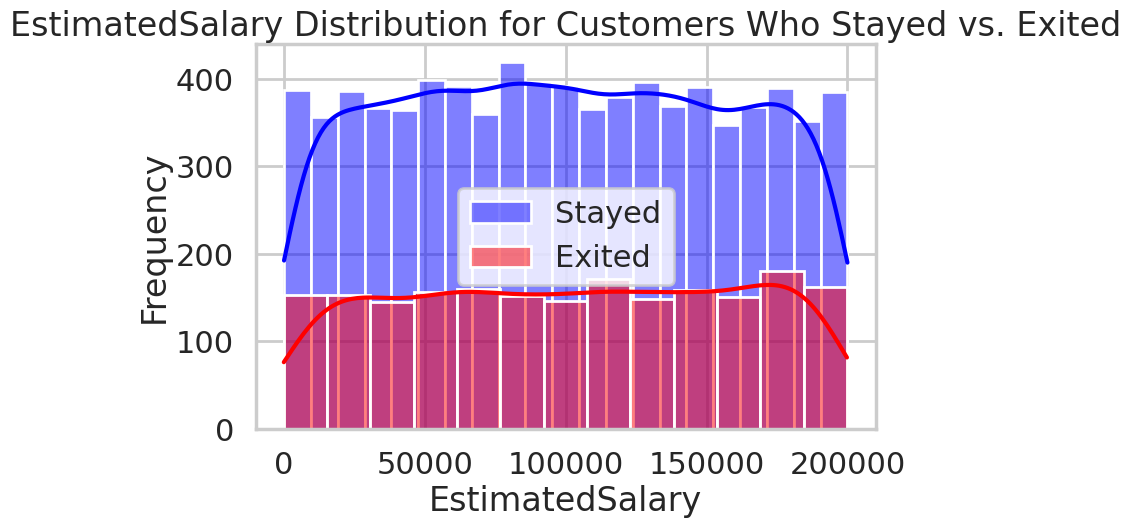

In [27]:
## TODO: Plot the distribution of EstimatedSalary for customers who stayed with the bank and those who left.
sns.histplot(df_0['EstimatedSalary'], color='blue', label='Stayed', kde=True)
sns.histplot(df_1['EstimatedSalary'], color='red', label='Exited', kde=True)
plt.title('EstimatedSalary Distribution for Customers Who Stayed vs. Exited')
plt.xlabel('EstimatedSalary')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [28]:
## TODO: Perform a t-test to compare the EstimatedSalary between customers who stayed and those who left.
t_stat_salary, p_val_salary = scipy.stats.ttest_ind(df_0['EstimatedSalary'], df_1['EstimatedSalary'], equal_var=False) # Welch's t-test
print(f"EstimatedSalary T-statistic: {t_stat_salary:.2f}")
print(f"EstimatedSalary P-value: {p_val_salary:.3f}")

EstimatedSalary T-statistic: -1.20
EstimatedSalary P-value: 0.229


### Using Bootstrapping

In [29]:
## TODO: Calculate the difference in means and shift the EstimatedSalary for both groups.
diff_means_salary = df_1['EstimatedSalary'].mean() - df_0['EstimatedSalary'].mean()
mean_salary = df['EstimatedSalary'].mean()

salary_stayed_shifted = df_0['EstimatedSalary'] - df_0['EstimatedSalary'].mean() + mean_salary
salary_exited_shifted = df_1['EstimatedSalary'] - df_1['EstimatedSalary'].mean() + mean_salary

In [30]:
## TODO: Calculate the bootstrap sample means for both groups and their difference.
np.random.seed(42)
bs_salary_stayed = bs_choice(salary_stayed_shifted, np.mean, 10000)
bs_salary_exited = bs_choice(salary_exited_shifted, np.mean, 10000)

bs_diff_salary = bs_salary_exited - bs_salary_stayed

In [31]:
## TODO: Calculate the p-value based on the bootstrap distribution of the difference in means.
p_value_bs_salary = np.sum(bs_diff_salary >= diff_means_salary) / len(bs_diff_salary)
print(f"Bootstrap p-value for EstimatedSalary: {p_value_bs_salary:.3f}")

Bootstrap p-value for EstimatedSalary: 0.115


### Conclusion (Estimated Salary)
Do we reject the Null Hypothesis ? Why ?

**Null Hypothesis (H0):** Estimated Salary of people who left the bank and who did not are similar.
**Alternative Hypothesis (H1):** Estimated Salary of people who left the bank and who did not are not similar.

Based on both the t-test (p-value: 0.229) and bootstrap (p-value: 0.115), both p-values are greater than the common significance level of 0.05. Therefore, we **fail to reject the Null Hypothesis**.

This indicates that there is no statistically significant difference in the estimated salaries between customers who stayed with the bank and those who exited.

## Final Conclusion
What will be the most helpful feature in predicting churning?

Based on our inferential statistical analysis, we found the following:

*   **Age:** Both the t-test (p-value < 0.001) and bootstrapping (p-value = 0.000) strongly indicate a statistically significant difference in age between customers who stayed and those who exited. Customers who exited tend to be older on average. **This is a highly significant feature.**

*   **Credit Score:** The t-test (p-value = 0.008) showed a statistically significant difference in credit scores. Customers who stayed tended to have slightly higher credit scores on average than those who exited. **This is a significant feature.**

*   **Balance:** The initial t-test (p-value < 0.001) suggested a significant difference in balance. However, upon further analysis, excluding customers with zero balances, the difference became non-significant (p-value = 0.174). This implies that the initial significance was driven by the large number of customers with zero balance. **Balance, when considering only customers with a positive balance, is not a significant feature in predicting churning.**

*   **Estimated Salary:** Both the t-test (p-value = 0.229) and bootstrapping (p-value = 0.115) indicated no statistically significant difference in estimated salaries between the two groups. **Estimated Salary is not a significant feature.**

**Overall, the most helpful feature in predicting churning appears to be Age, followed by Credit Score.** While Balance initially seemed significant, its importance diminishes when accounting for customers with zero balances. Estimated Salary shows no significant predictive power in this analysis.

## Building a Churn Prediction Model

Based on the feedback, we will now proceed to build a machine learning model to predict customer churn. This involves several steps: data preprocessing, splitting the data into training and testing sets, training a classification model, and evaluating its performance.

### Data Preprocessing

We need to encode categorical features and scale numerical features before training a model.

In [32]:
import pandas as pd # Ensure pandas is imported
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure df is loaded. If it's not in the current environment, reload it.
# This makes the ML pipeline robust against kernel resets or partial execution.
if 'df' not in locals() and 'df' not in globals():
    # Re-define file_url for robustness, even if defined earlier in the notebook
    file_url = 'https://raw.githubusercontent.com/sharmaroshan/Churn-Modelling-Dataset/master/Churn_Modelling.csv'
    df = pd.read_csv(file_url)

# Define target and features
X = df.drop('Exited', axis=1)
y = df['Exited']

In [33]:
# Identify categorical and numerical features
categorical_features = ['Geography', 'Gender']
numerical_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

# Create a column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='drop'
)

# Create a pipeline with preprocessing and a Logistic Regression model
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42))
])

### Data Splitting

We will split the dataset into training and testing sets to evaluate the model's performance on unseen data.

In [34]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (8000, 13)
Testing data shape: (2000, 13)


### Model Training

Now, we will train a Logistic Regression model on the preprocessed training data.

In [35]:
# Train the model
model.fit(X_train, y_train)
print("Model training complete.")

Model training complete.


### Model Evaluation

Finally, we will evaluate the model's performance using common classification metrics and a confusion matrix.

Accuracy: 0.8080
Precision: 0.5891
Recall: 0.1867
F1-Score: 0.2836


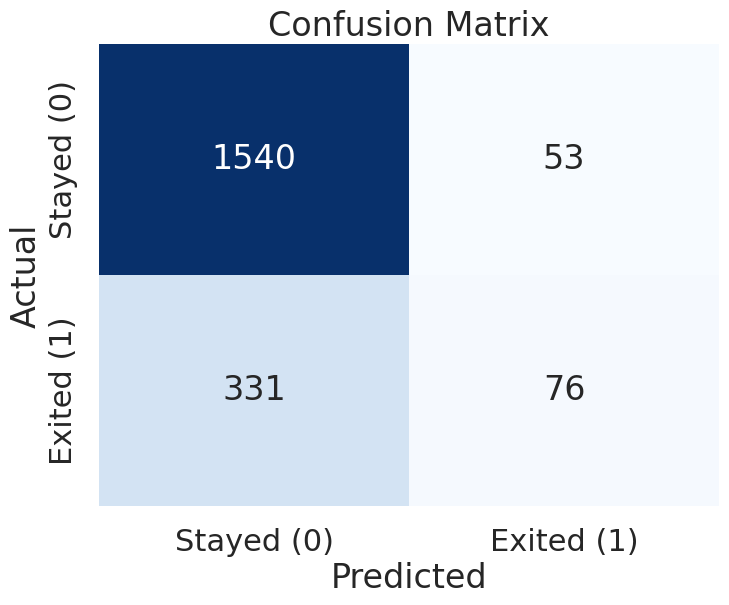

In [36]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Stayed (0)', 'Exited (1)'],
            yticklabels=['Stayed (0)', 'Exited (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()